SHAPE: (20, 9)

INFO:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   StudentID          20 non-null     int64
 1   Gender             20 non-null     str  
 2   Math               20 non-null     int64
 3   Reading            20 non-null     int64
 4   Writing            20 non-null     int64
 5   StudyHours         20 non-null     int64
 6   Attendance         20 non-null     int64
 7   ParentalEducation  20 non-null     str  
 8   Passed             20 non-null     str  
dtypes: int64(6), str(3)
memory usage: 1.5 KB
None

DESCRIBE:
       StudentID       Math    Reading    Writing  StudyHours  Attendance
count   20.00000  20.000000  20.000000  20.000000   20.000000    20.00000
mean    10.50000  75.350000  77.300000  76.400000    5.050000    86.05000
std      5.91608  12.799157  12.113933  12.938722    2.282081     9.41709
min      1.00000  55.00

C:\Users\DELL\AppData\Local\Temp\ipykernel_19676\855100258.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


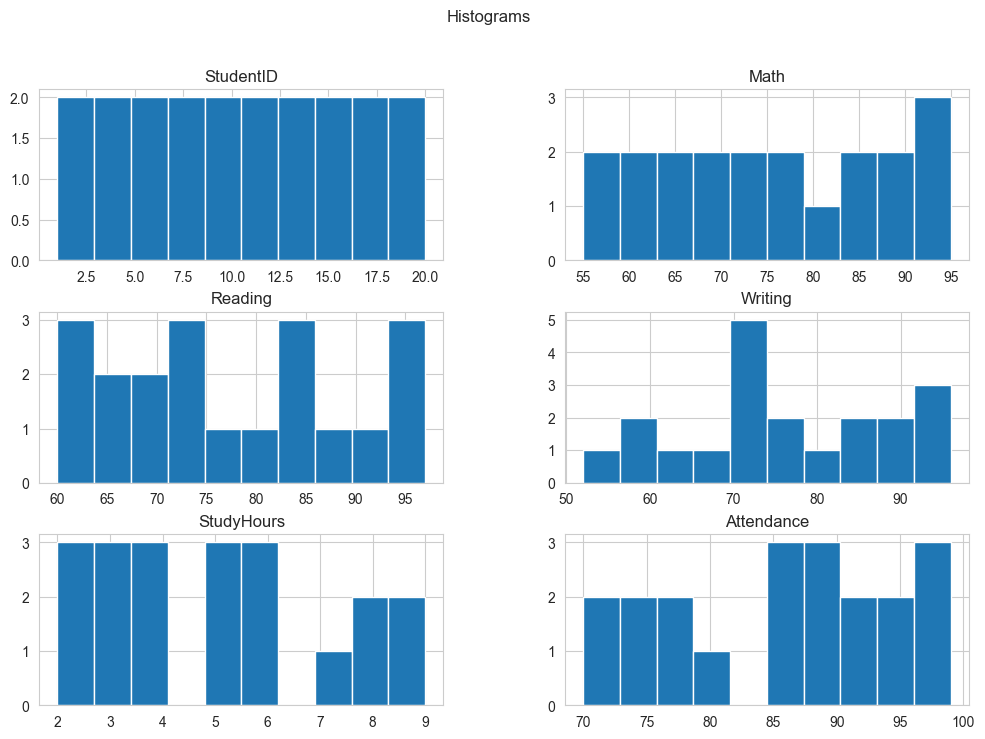

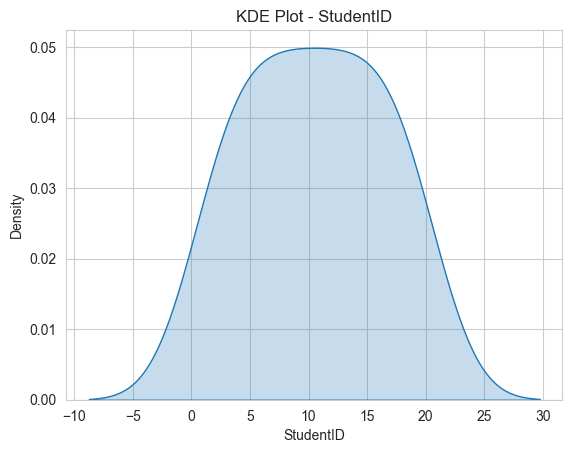

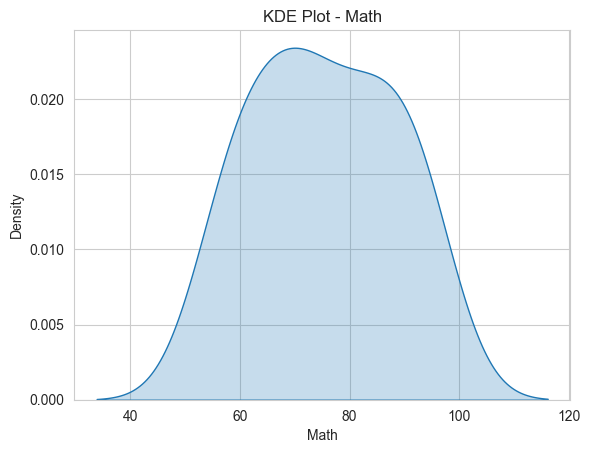

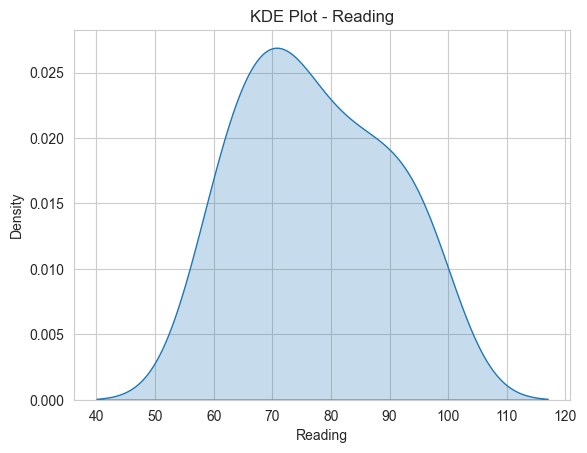

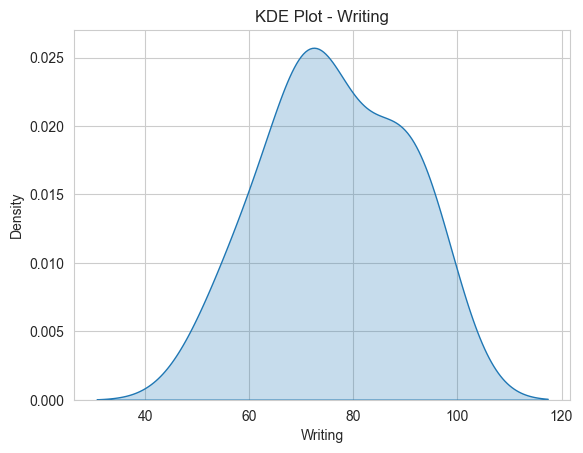

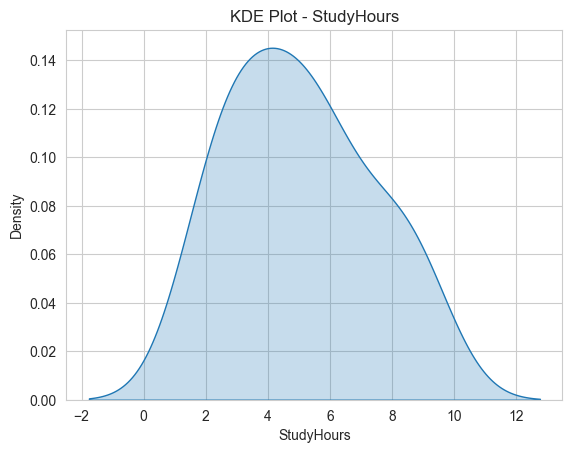

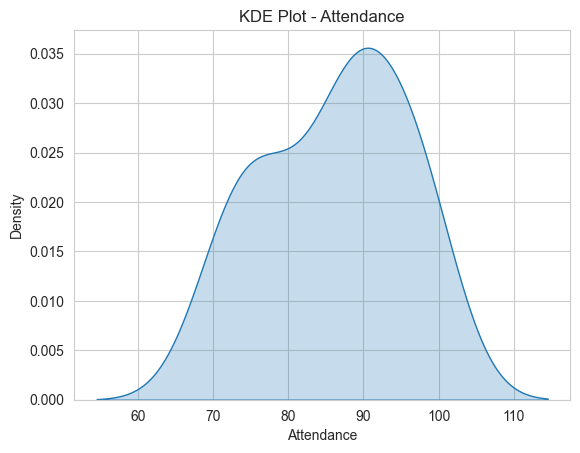

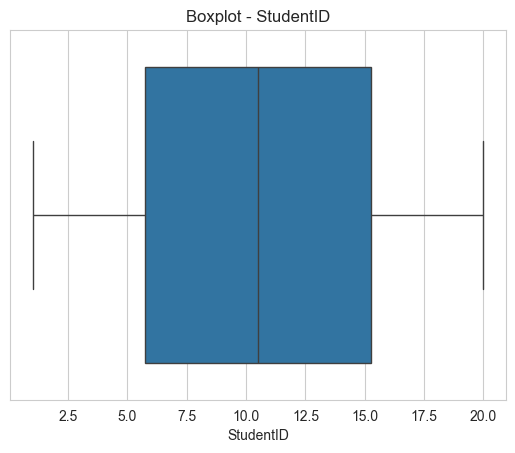

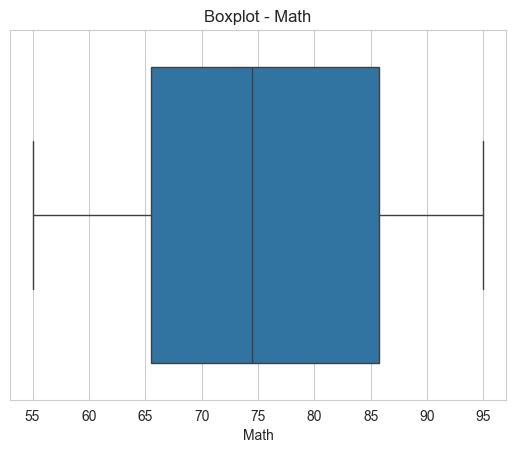

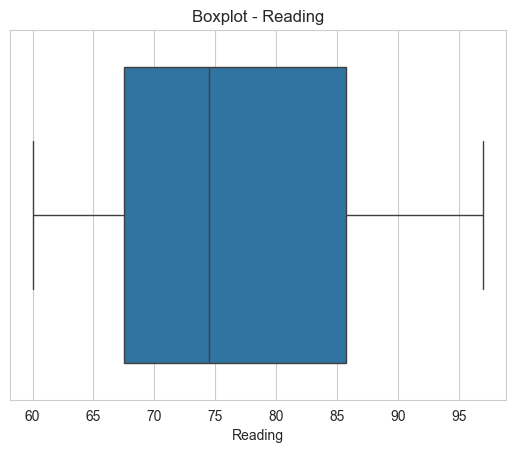

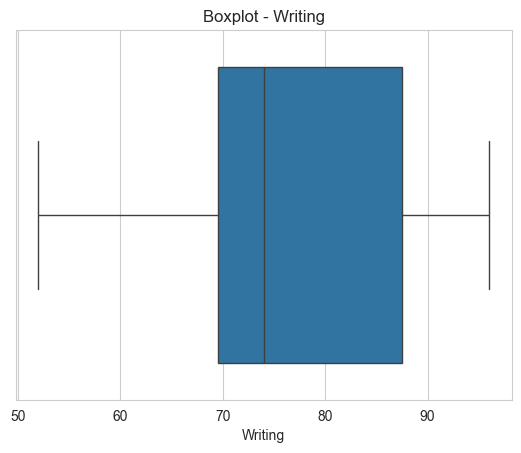

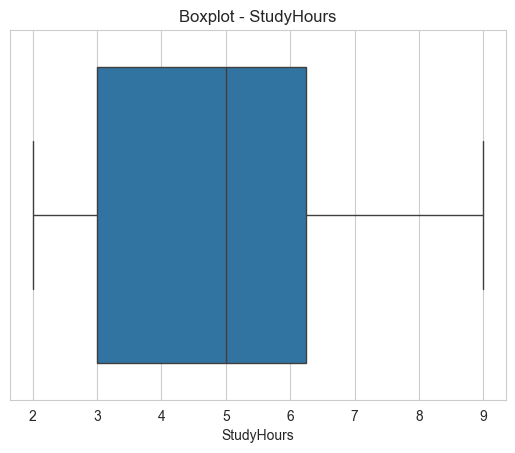

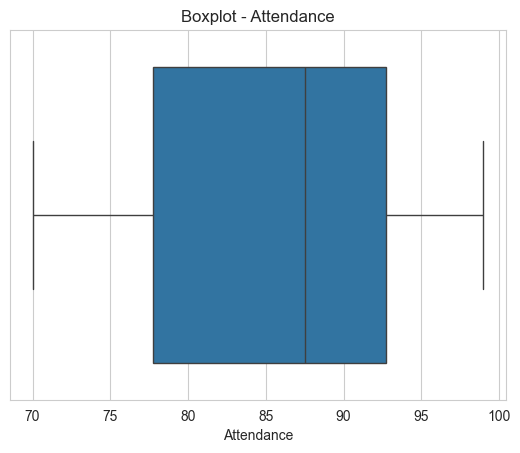

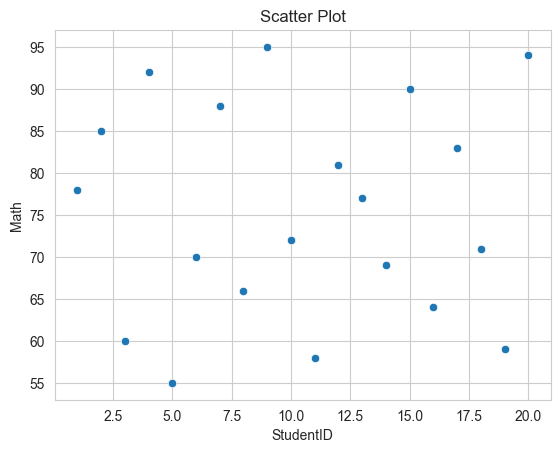

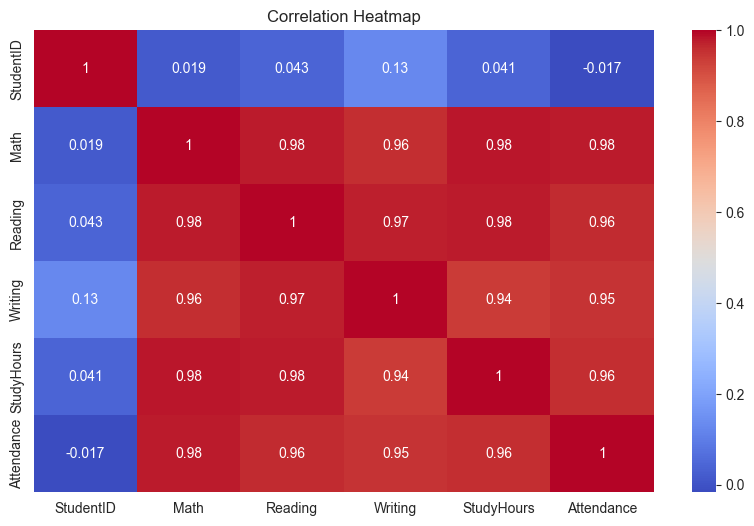


EDA Completed Successfully


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# =========================
# LOAD DATASET
# =========================
df = pd.read_csv("studentdata.csv")

print("SHAPE:", df.shape)
print("\nINFO:")
print(df.info())
print("\nDESCRIBE:")
print(df.describe())

# =========================
# DUPLICATES CHECK
# =========================
print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("After removing duplicates:", df.duplicated().sum())

# =========================
# MISSING VALUES
# =========================
print("\nMissing values BEFORE:")
print(df.isnull().sum())

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

# =========================
# IMPUTATION STRATEGY
# (Median for numeric, Mode for categorical)
# Reason: Median reduces impact of outliers in student marks dataset
# =========================
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values AFTER:")
print(df.isnull().sum())

# =========================
# VISUAL ANALYSIS
# =========================

# Histograms / Distribution
df.hist(figsize=(12, 8))
plt.suptitle("Histograms")
plt.show()

# KDE plots
for col in num_cols:
    plt.figure()
    sns.kdeplot(df[col], fill=True)
    plt.title(f"KDE Plot - {col}")
    plt.show()

# Boxplots (Outliers)
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

# Scatter Plot
if len(num_cols) >= 2:
    plt.figure()
    sns.scatterplot(x=df[num_cols[0]], y=df[num_cols[1]])
    plt.title("Scatter Plot")
    plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# =========================
# INSIGHTS FOR ML MODELING
# =========================

# Outliers:
# - Present in some numeric columns
# - May affect linear models
# - Tree models handle better

# Collinearity:
# - Some features are highly correlated
# - Can cause multicollinearity issues

# Recommendations:
# - Use feature selection
# - Try Ridge/Lasso regression
# - Handle outliers if needed

print("\nEDA Completed Successfully")